# Drifting cored elliptical power law

In [1]:
import numpy as np

from matplotlib import pyplot as plt
# Use TeX
from matplotlib import rc
rc('text', usetex=True)
rc('font', family='serif')
rc('font', size=18)

from matplotlib.patches import Ellipse, Circle

from scipy.differentiate import derivative, jacobian

# 1. Radial profile

We parameterise the potential as
$$
\psi(\theta) = \psi_0\left[1 + \left(\frac{\theta}{\theta_{\rm c}}\right)^s\right]^{\frac{3-\gamma}{s}}
$$
with
$$
\psi_0
\equiv
\frac{\theta_{\rm E}^2}{3-\gamma}
\left(\frac{\theta_{\rm c}}{\theta_{\rm E}}\right)^s
\left[1 + \left(\frac{\theta_{\rm E}}{\theta_{\rm c}}\right)^{s}\right]^{1-\frac{3-\gamma}{s}}
$$
ensuring that the Einstein radius is $\theta_{\rm E}$.

In [2]:
def cPL(theta, theta_E, theta_core, sharpness, outer_slope):
    """
    Axially symmetric cored power law potential.
    """
    
    power = (3 - outer_slope) / sharpness
    R = theta_core / theta_E
    
    # normalisation to ensure that the Einstein radius is theta_E
    psi0 = theta_E**2 / (3 - outer_slope) * R**sharpness * (1 + R**(-sharpness))**(1 - power)
    
    psi  = psi0 * (1 + (theta/theta_core)**sharpness)**power
    
    return psi

Check normalisation
$$
\bar{\kappa}(<\theta) = \frac{1}{\theta} \frac{{\rm d}\psi}{{\rm d}\theta}
$$
and we must have $\bar{\kappa}(<\theta_{\rm E})=1$

In [3]:
theta_E = 1.43
theta_core = 0.56
sharpness = 1.86
outer_slope = 2.3

potential = lambda theta: cPL(theta, theta_E, theta_core, sharpness, outer_slope)

theta = np.logspace(-1, 1, 100)
dpsi = derivative(potential, theta)

kappa_bar = dpsi.df / theta

/var/folders/fc/8ml2gs_91pd0cfcp6dyg98kc0000gn/T/ipykernel_63979/1179458101.py:12: RuntimeWarning: invalid value encountered in power
  psi  = psi0 * (1 + (theta/theta_core)**sharpness)**power


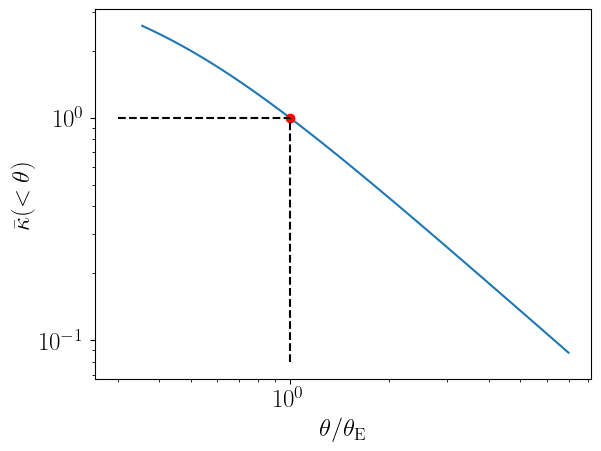

In [4]:
plt.loglog(theta/theta_E, kappa_bar)
plt.loglog([1], [1], 'ro')
plt.loglog([3e-1, 1], [1, 1], 'k--')
plt.loglog([1, 1], [8e-2, 1], 'k--')
plt.xlabel(r'$\theta/\theta_{\rm E}$')
plt.ylabel(r'$\bar{\kappa}(<\theta)$')
plt.show()

This radial profile is justified by the fact that it provides a very good fit to the $\bar{\kappa}(<\theta)$ of simulated galaxies, up to about 10 Einstein radii.

# 2. Elliptical profile with a drift

## Elliptical radius

Assume that the plane is covered by a family of ellipses with constant ellipticity $(e_1, e_2)$, but whose center drifts linearly with the elliptical radius $\zeta=\sqrt{ab}$ ($a, b$ being the semi-major and semi-minor axis), that is $x_0(\zeta)=D_x \zeta$ and $y_0(\zeta)=D_y\zeta$. We use the elliptical radius $\zeta$ as a label for the ellipses.

A point $(x, y)$ of the plane belongs to the ellipse with elliptical radius
$$
\zeta(x, y)
=
\left(1 - \boldsymbol{D}^T \boldsymbol{E} \boldsymbol{D}\right)^{-1} 
\left[
    \sqrt{(1 - \boldsymbol{D}^T \boldsymbol{E} \boldsymbol{D}) \, \boldsymbol{X}^T \boldsymbol{E} \boldsymbol{X}}
    - \boldsymbol{D}^T \boldsymbol{E} \boldsymbol{X} \right] ,
$$
where $\boldsymbol{X}=(x, y)$, $\boldsymbol{D}=(D_x, D_y)$ is the drift-rate vector, and the ellipse matrix reads
$$
\boldsymbol{E} =
\sqrt{1+e^2}\,\boldsymbol{1}_2
-
\begin{bmatrix}
e_1 & e_2 \\
e_2 & -e_1
\end{bmatrix}
=
\begin{bmatrix}
\cos\phi & -\sin\phi \\
\sin\phi & \cos\phi
\end{bmatrix}
\begin{bmatrix}
q & 0 \\
0 & 1/q
\end{bmatrix}
\begin{bmatrix}
\cos\phi & \sin\phi \\
-\sin\phi & \cos\phi
\end{bmatrix}
$$
if $(e_1, e_2)=e(\cos 2\phi, \sin2\phi)$.

Note that the drift rate cannot be too large, otherwise successive ellipses may overlap, implying that $(x, y)\mapsto \zeta(x, y)$ would be mutliply valued. We do not want this. The constraint on the magnitude of the drift rate is
$$
\boldsymbol{D}^T \boldsymbol{E} \boldsymbol{D} < 1 ,
$$
which we can see is also the condition for the above expression of $\zeta(x, y)$ to be well defined.

In [5]:
def elliptical_radius(x, y, e1=0, e2=0, drift_x=0, drift_y=0):
    """
    Calculate the elliptical radius zeta of the ellipse containing (x, y),
    assuming constant ellipticity (e1, e2) and a linear drift of the centre
    with radius:
    x0 = drift_x * zeta
    y0 = drift_y * zeta
    """

    # ellipse matrix and inner product

    E_xx = (1 + e1**2 + e2**2)**0.5 - e1
    E_xy = - e2
    E_yx = - e2
    E_yy = (1 + e1**2 + e2**2)**0.5 + e1

    
    def EV(vx, vy):
        
        "Matrix product of E with vector (vx, vy)"
        
        EV_x = E_xx * vx + E_xy * vy
        EV_y = E_yx * vx + E_yy * vy
        
        return EV_x, EV_y

    
    def Edot(vx, vy, wx, wy):
        "Inner product V.EW"

        EWx, EWy = EV(wx, wy)
        VEW = vx * EWx + vy * EWy
        
        return VEW
        
      
    DED = Edot(drift_x, drift_y, drift_x, drift_y)
    
    # drift test: ensures that the ellipses do not overlap
    if DED >= 1:
        raise ValueError("The drift rate is too large.")
    
    DEX = Edot(drift_x, drift_y, x, y)
    XEX = Edot(x, y, x, y)

    # Final expression of the elliptical radius
    
    zeta = (((1 - DED) * XEX + DEX**2)**0.5 - DEX) / (1 - DED)

    
    return zeta

Test that it works by randomly picking points, and checking that they fall on the right ellipse.

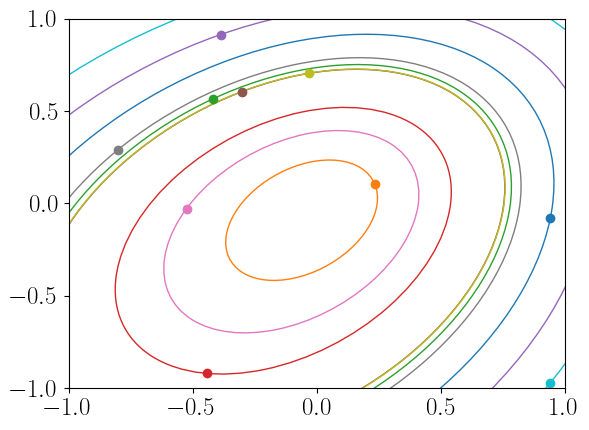

In [6]:
# properties of the ellipse set
e       = 0.4
phi     = 0.87
e1      = e * np.cos(2*phi)
e2      = e * np.sin(2*phi)
drift_x = -0.2
drift_y = -0.3

# generate a set of N random points in [-1, 1]^2
N = 10
x = 2 * np.random.random_sample(N) - 1
y = 2 * np.random.random_sample(N) - 1

# get the corresponding elliptical radii
zetas = elliptical_radius(x, y, e1=e1, e2=e2, drift_x=drift_x, drift_y=drift_y)

# plot the points and the ellipses
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots()

for i, zeta in enumerate(zetas):
    
    x0 = drift_x * zeta
    y0 = drift_y * zeta
    q = (1 + e**2)**0.5 - e
    a = zeta / q**0.5
    b = zeta * q**0.5

    colour = colours[i% len(colours)]
    
    ellipse = Ellipse(
    xy=(x0, y0),
    width=2*a,
    height=2*b,
    angle=phi * 180 / np.pi,
    facecolor="none",
    edgecolor=colour
    )
    
    ax.plot(x[i], y[i], 'o', color=colour)
    ax.add_artist(ellipse)

plt.xlim([-1, 1])
plt.ylim([-1, 1])
plt.show()

## Elliptical potential

Assume that the above ellipses are the isopotential contours. Then
$$
\psi(x, y) = \psi[\zeta(x, y)] .
$$

In [7]:
def cdEPL(x, y, theta_E, theta_core, sharpness, outer_slope, e1=0, e2=0, drift_x=0, drift_y=0):
    """
    Potential of a cored elliptical power law with drifting elliptical contours.
    """

    zeta = elliptical_radius(x, y, e1, e2, drift_x, drift_y)
    psi = cPL(zeta, theta_E, theta_core, sharpness, outer_slope)

    return psi

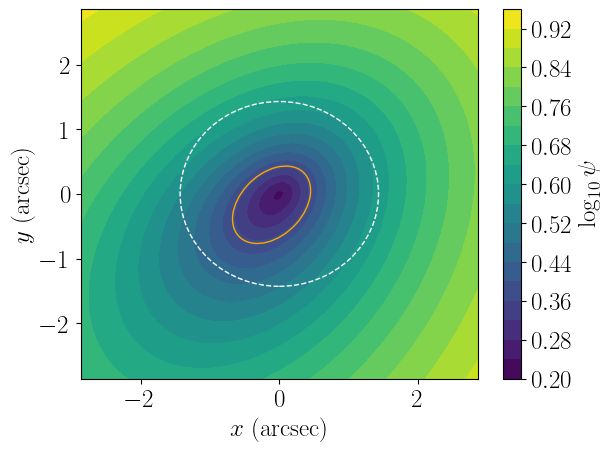

In [8]:
# radial parameters
theta_E = 1.43
theta_core = 0.56
sharpness = 1.54
outer_slope = 2.3


# ellipse parameters
e       = 0.4
phi     = 0.87
e1      = e * np.cos(2*phi)
e2      = e * np.sin(2*phi)
drift_x = -0.2
drift_y = -0.3


# calculate the potential on a mesh
x = np.linspace(-2*theta_E, 2*theta_E, 100)
y = np.linspace(-2*theta_E, 2*theta_E, 100)
X, Y = np.meshgrid(x, y)

potential = cdEPL(X, Y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)


# plot the potential

fig, ax = plt.subplots()

contours = ax.contourf(X, Y, np.log10(potential), levels=20)
fig.colorbar(contours, ax=ax, label=r'$\log_{10}\psi$')

# Einstein radius for indication
ax.add_artist(Circle(xy=(0, 0), radius=theta_E, facecolor="none", edgecolor='white', ls='--'))

# Core ellipse
x0 = drift_x * theta_core
y0 = drift_y * theta_core
q = (1 + e**2)**0.5 - e
a = theta_core / q**0.5
b = theta_core * q**0.5
ellipse_core = Ellipse(
    xy=(x0, y0),
    width=2*a,
    height=2*b,
    angle=phi * 180 / np.pi,
    facecolor="none",
    edgecolor='orange'
    )
ax.add_artist(ellipse_core)

plt.xlabel(r"$x$ (arcsec)")
plt.ylabel(r"$y$ (arcsec)")
plt.show()

## Displacement angle

$$
\alpha_i = \partial_i \psi = \psi'(\zeta) \partial_i\zeta
$$

The derivative of the radial profile reads
$$
\psi'(\theta)
=
\theta_{\rm E} \left(\frac{\theta}{\theta_{\rm E}}\right)^{s-1}
\left[\frac{\theta_{\rm c}^s + \theta^s}{\theta_{\rm c}^s + \theta_{\rm E}^s}\right]^{\frac{3-\gamma}{s}-1}
$$
and the gradient of the elliptical radius is
$$
\partial_i\zeta = \frac{E_{ij} (\theta_j - D_j\zeta)}{\zeta + D_k E_{kj}(\theta_j - D_j\zeta)}
$$
with the ellipse matrix
$$
\boldsymbol{E} =
\sqrt{1+e^2}\,\boldsymbol{1}_2
-
\begin{bmatrix}
e_1 & e_2 \\
e_2 & -e_1
\end{bmatrix}
$$
and $\boldsymbol{D}$ the drift rate.

In [9]:
def displacement(x, y, theta_E, theta_core, sharpness, outer_slope, e1=0, e2=0, drift_x=0, drift_y=0):
    """
    Displacement angle of a cored elliptical power law with drifting elliptical contours.
    """

    # elliptical radius
    
    zeta = elliptical_radius(x, y, e1, e2, drift_x, drift_y)

    
    # radial displacement (psi')
    
    power = (3 - outer_slope) / sharpness
    alpha0 = theta_E * (zeta/theta_E)**(sharpness-1) * (
        (theta_core**sharpness + zeta**sharpness)/(theta_core**sharpness + theta_E**sharpness))**(power - 1)

    
    # ellipse matrix

    E_xx = (1 + e1**2 + e2**2)**0.5 - e1
    E_xy = - e2
    E_yx = - e2
    E_yy = (1 + e1**2 + e2**2)**0.5 + e1

    def EV(vx, vy):
        
        "Matrix product of E with vector (vx, vy)"
        
        EV_x = E_xx * vx + E_xy * vy
        EV_y = E_yx * vx + E_yy * vy
        
        return EV_x, EV_y

    
    # displaced position
    
    x1 = x - drift_x * zeta
    y1 = y - drift_y * zeta

    x2, y2 = EV(x1, y1)
    
    DX2 = drift_x * x2 + drift_y * y2


    # final displacement
    
    alpha_x = alpha0 * x2 / (zeta + DX2)
    alpha_y = alpha0 * y2 / (zeta + DX2)

    return alpha_x, alpha_y

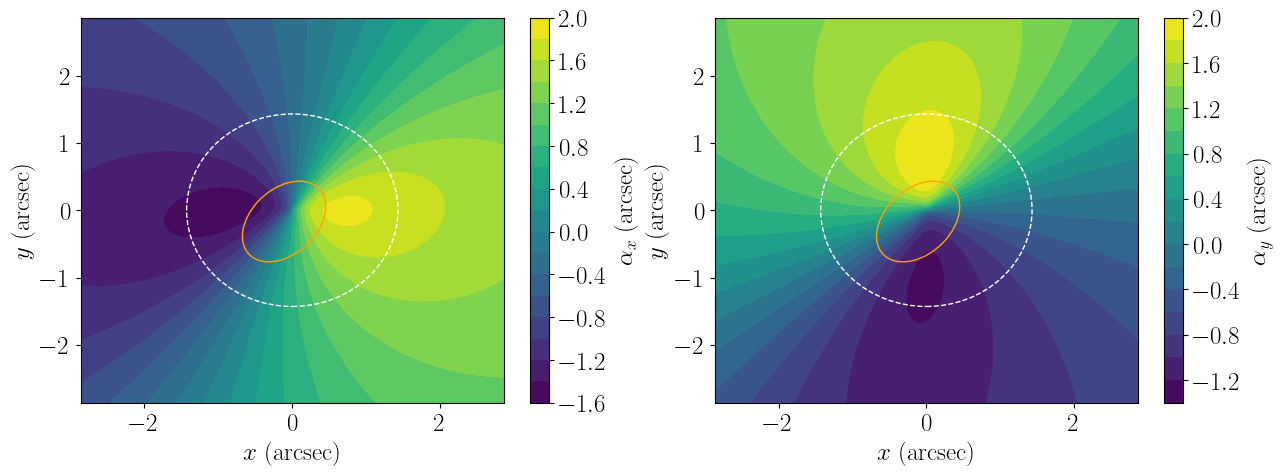

In [10]:
# radial parameters
theta_E = 1.43
theta_core = 0.56
sharpness = 1.54
outer_slope = 2.3


# ellipse parameters
e       = 0.4
phi     = 0.87
e1      = e * np.cos(2*phi)
e2      = e * np.sin(2*phi)
drift_x = -0.2
drift_y = -0.3


# calculate the displacement on a mesh
x = np.linspace(-2*theta_E, 2*theta_E, 100)
y = np.linspace(-2*theta_E, 2*theta_E, 100)
X, Y = np.meshgrid(x, y)
alpha_x, alpha_y = displacement(X, Y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)


# plot alpha_x and alpha_x
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax0 = axes[0]
contours = ax0.contourf(X, Y, alpha_x, levels=20)
ax0.set_xlabel(r"$x$ (arcsec)")
ax0.set_ylabel(r"$y$ (arcsec)")
fig.colorbar(contours, ax=ax0, label=r'$\alpha_x$ (arcsec)')

ax1 = axes[1]
contours = ax1.contourf(X, Y, alpha_y, levels=20)
ax1.set_xlabel(r"$x$ (arcsec)")
ax1.set_ylabel(r"$y$ (arcsec)")
fig.colorbar(contours, ax=ax1, label=r'$\alpha_y$ (arcsec)')

for ax in axes:

    # Einstein radius for indication
    ax.add_artist(Circle(xy=(0, 0), radius=theta_E, facecolor="none", edgecolor='white', ls='--'))
    
    # Core ellipse
    x0 = drift_x * theta_core
    y0 = drift_y * theta_core
    q = (1 + e**2)**0.5 - e
    a = theta_core / q**0.5
    b = theta_core * q**0.5
    ellipse_core = Ellipse(
        xy=(x0, y0),
        width=2*a,
        height=2*b,
        angle=phi * 180 / np.pi,
        facecolor="none",
        edgecolor='orange'
        )
    ax.add_artist(ellipse_core)

plt.show();

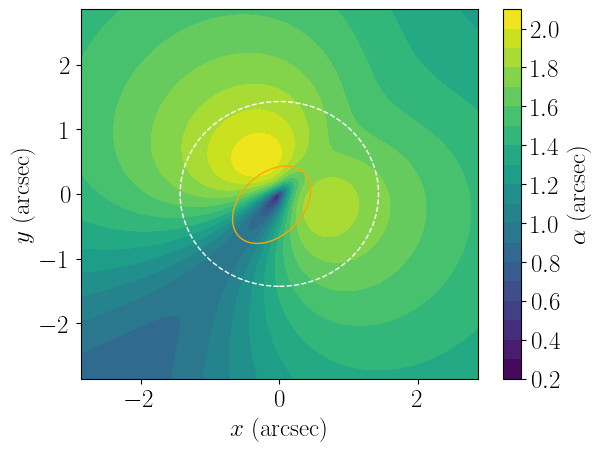

In [11]:
# plot the magnitude of the displacement angle

alpha = (alpha_x**2 + alpha_y**2)**0.5

fig, ax = plt.subplots()

contours = ax.contourf(X, Y, alpha, levels=20)
fig.colorbar(contours, ax=ax, label=r'$\alpha$ (arcsec)')

# Einstein radius for indication
ax.add_artist(Circle(xy=(0, 0), radius=theta_E, facecolor="none", edgecolor='white', ls='--'))

# Core ellipse
x0 = drift_x * theta_core
y0 = drift_y * theta_core
q = (1 + e**2)**0.5 - e
a = theta_core / q**0.5
b = theta_core * q**0.5
ellipse_core = Ellipse(
    xy=(x0, y0),
    width=2*a,
    height=2*b,
    angle=phi * 180 / np.pi,
    facecolor="none",
    edgecolor='orange'
    )
ax.add_artist(ellipse_core)

plt.xlabel(r"$x$ (arcsec)")
plt.ylabel(r"$y$ (arcsec)")
plt.show()

Check that it does correspond to the derivatives of $\psi$.

In [12]:
f = lambda x, y: cdEPL(x, y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)
res = derivative(f, X, args=(Y,))
alpha_x_num = res.df
diff_x = alpha_x - alpha_x_num

f = lambda y, x: cdEPL(x, y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)
res = derivative(f, Y, args=(X,))
alpha_y_num = res.df
diff_y = alpha_y - alpha_y_num

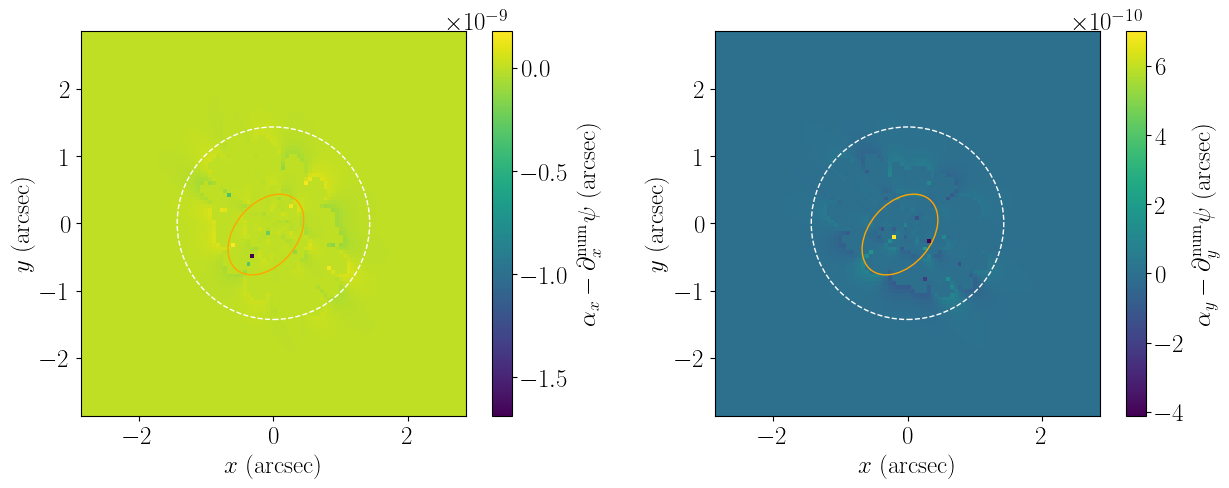

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax0 = axes[0]
im = ax0.imshow(diff_x, extent=(-2*theta_E, 2*theta_E, -2*theta_E, 2*theta_E))
ax0.set_xlabel(r"$x$ (arcsec)")
ax0.set_ylabel(r"$y$ (arcsec)")
fig.colorbar(im, ax=ax0, label=r'$\alpha_x-\partial_x^{\rm num}\psi$ (arcsec)')

ax1 = axes[1]
im = ax1.imshow(diff_y, extent=(-2*theta_E, 2*theta_E, -2*theta_E, 2*theta_E))
ax1.set_xlabel(r"$x$ (arcsec)")
ax1.set_ylabel(r"$y$ (arcsec)")
fig.colorbar(im, ax=ax1, label=r'$\alpha_y-\partial_y^{\rm num}\psi$ (arcsec)')


for ax in axes:

    # Einstein radius for indication
    ax.add_artist(Circle(xy=(0, 0), radius=theta_E, facecolor="none", edgecolor='white', ls='--'))
    
    # Core ellipse
    x0 = drift_x * theta_core
    y0 = drift_y * theta_core
    q = (1 + e**2)**0.5 - e
    a = theta_core / q**0.5
    b = theta_core * q**0.5
    ellipse_core = Ellipse(
        xy=(x0, y0),
        width=2*a,
        height=2*b,
        angle=phi * 180 / np.pi,
        facecolor="none",
        edgecolor='orange'
        )
    ax.add_artist(ellipse_core)

plt.show();

## Hessian matrix

$$
\partial_i \partial_j \psi = \psi''(\zeta) \partial_i \zeta \partial_j \zeta + \psi'(\zeta) \partial_i\partial_j\zeta
$$

The first derivative, $\psi'$, was already computed for the displacement angle, as well as the gradient of the ellitpical radius, $\partial_i\zeta$.

The second derivative of the radial profile is found to read
$$
\psi''(\theta) = \left[ s-1 + (3-\gamma-s)\frac{\theta^s}{\theta_{\rm c}^s + \theta^s} \right] \frac{\psi'(\theta)}{\theta} \ .
$$

The Hessian of the elliptical angle is
$$
\partial_i \partial_j \zeta
=
\left[\zeta + D_k E_{kl}(\theta_l - D_l\zeta)\right]^{-1}
\left[E_{ij} - 2 D_k E_{k(i} \partial_{j)}\zeta - (1-E_{kl} D_k D_l) \partial_i \zeta \partial_j \zeta\right]
$$

In [14]:
def hessian(x, y, theta_E, theta_core, sharpness, outer_slope, e1=0, e2=0, drift_x=0, drift_y=0):
    """
    Hessian matrix of a cored elliptical power law with drifting elliptical contours.
    """

    # elliptical radius
    
    zeta = elliptical_radius(x, y, e1, e2, drift_x, drift_y)

    
    # first radial derivative (psi')
    
    power = (3 - outer_slope) / sharpness
    alpha0 = theta_E * (zeta/theta_E)**(sharpness-1) * (
        (theta_core**sharpness + zeta**sharpness)/(theta_core**sharpness + theta_E**sharpness))**(power - 1)

    
    # second radial derivative (psi'')
    
    kappa0 = (sharpness - 1 + (3 - outer_slope - sharpness)
              * zeta**sharpness / (theta_core**sharpness + zeta**sharpness)) * alpha0 / zeta

    
     # ellipse matrix and inner product

    E_xx = (1 + e1**2 + e2**2)**0.5 - e1
    E_xy = - e2
    E_yx = - e2
    E_yy = (1 + e1**2 + e2**2)**0.5 + e1

    
    def EV(vx, vy):
        
        "Matrix product of E with vector (vx, vy)"
        
        EV_x = E_xx * vx + E_xy * vy
        EV_y = E_yx * vx + E_yy * vy
        
        return EV_x, EV_y

    
    # gradient of the elliptical radius

    x1 = x - drift_x * zeta
    y1 = y - drift_y * zeta

    x2, y2 = EV(x1, y1)
    DX2 = drift_x * x2 + drift_y * y2

    zeta_x = x2 / (zeta + DX2)
    zeta_y = y2 / (zeta + DX2)

    
    # hessian of the elliptical radius

    ED_x, ED_y = EV(drift_x, drift_y)
    DED        = drift_x * ED_x + drift_y * ED_y 

    zeta_xx = (E_xx - ED_x * zeta_x - ED_x * zeta_x - (1 - DED) * zeta_x * zeta_x) / (zeta - DX2)
    zeta_xy = (E_xy - ED_x * zeta_y - ED_y * zeta_x - (1 - DED) * zeta_x * zeta_y) / (zeta - DX2)
    zeta_yx = zeta_xy
    zeta_yy = (E_yy - ED_y * zeta_y - ED_y * zeta_y - (1 - DED) * zeta_y * zeta_y) / (zeta - DX2)


    # full Hessian

    H_xx = kappa0 * zeta_x * zeta_x + alpha0 * zeta_xx
    H_xy = kappa0 * zeta_x * zeta_y + alpha0 * zeta_xy
    H_yx = H_xy
    H_yy = kappa0 * zeta_y * zeta_y + alpha0 * zeta_yy


    return H_xx, H_xy, H_yx, H_yy

Plot the convergence and shear

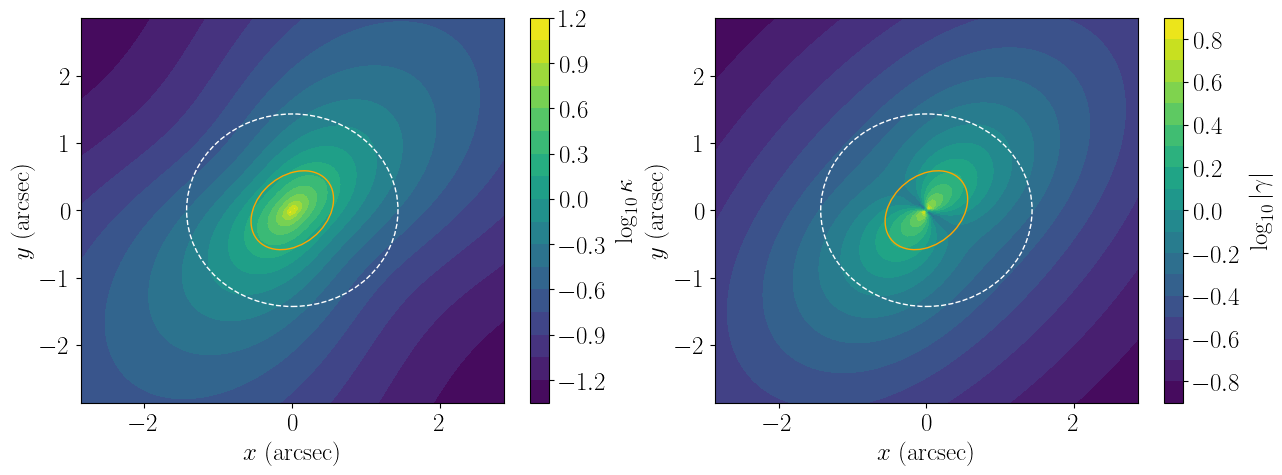

In [15]:
# radial parameters
theta_E = 1.43
theta_core = 0.56
sharpness = 1.54
outer_slope = 2.3


# ellipse parameters
e       = 0.3
phi     = 0.87
e1      = e * np.cos(2*phi)
e2      = e * np.sin(2*phi)
drift_x = 0
drift_y = 0


# calculate the convergence and shear on a mesh
x = np.linspace(-2*theta_E, 2*theta_E, 100)
y = np.linspace(-2*theta_E, 2*theta_E, 100)
X, Y = np.meshgrid(x, y)
H_xx, H_xy, H_yx, H_yy = hessian(X, Y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)
kappa = (H_xx + H_yy) / 2
gamma1 = H_xx - kappa
gamma2 = H_xy
gamma = (gamma1**2 + gamma2**2)**0.5


# plot kappa and gamma
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax0 = axes[0]
contours = ax0.contourf(X, Y, np.log10(kappa), levels=20)
ax0.set_xlabel(r"$x$ (arcsec)")
ax0.set_ylabel(r"$y$ (arcsec)")
fig.colorbar(contours, ax=ax0, label=r'$\log_{10}\kappa$')

ax1 = axes[1]
contours = ax1.contourf(X, Y, np.log10(gamma), levels=20)
ax1.set_xlabel(r"$x$ (arcsec)")
ax1.set_ylabel(r"$y$ (arcsec)")
fig.colorbar(contours, ax=ax1, label=r'$\log_{10}|\gamma|$')

for ax in axes:

    # Einstein radius for indication
    ax.add_artist(Circle(xy=(0, 0), radius=theta_E, facecolor="none", edgecolor='white', ls='--'))
    
    # Core ellipse
    x0 = drift_x * theta_core
    y0 = drift_y * theta_core
    q = (1 + e**2)**0.5 - e
    a = theta_core / q**0.5
    b = theta_core * q**0.5
    ellipse_core = Ellipse(
        xy=(x0, y0),
        width=2*a,
        height=2*b,
        angle=phi * 180 / np.pi,
        facecolor="none",
        edgecolor='orange'
        )
    ax.add_artist(ellipse_core)

plt.show();

Check that the analytical Hessian matrix is correct

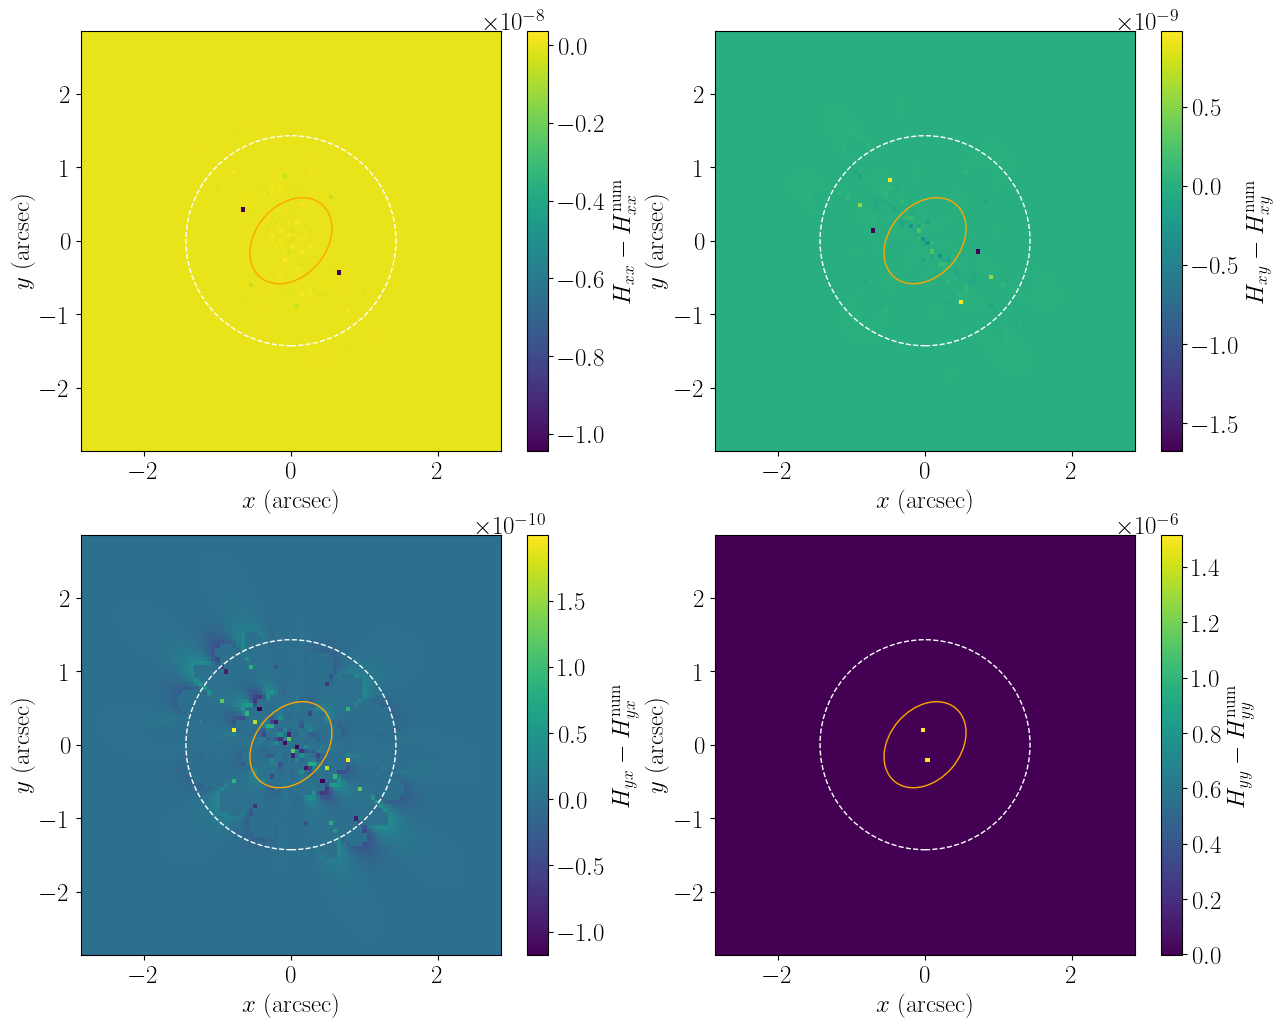

In [16]:
# analytical evaluation of the Hessian

H_xx, H_xy, H_yx, H_yy = hessian(X, Y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)


# numerical evaluation of the Hessian

# derivatives wrt x
a_x = lambda x, y: displacement(x, y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)[0]
a_y = lambda x, y: displacement(x, y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)[1]

res_x = derivative(a_x, X, args=(Y,))
res_y = derivative(a_y, X, args=(Y,))

H_xx_num = res_x.df
H_xy_num = res_y.df
diff_xx = H_xx - H_xx_num
diff_xy = H_xy - H_xy_num

# derivatives wrt y
a_x = lambda y, x: displacement(x, y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)[0]
a_y = lambda y, x: displacement(x, y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)[1]

res_x = derivative(a_x, Y, args=(X,))
res_y = derivative(a_y, Y, args=(X,))

H_yx_num = res_x.df
H_yy_num = res_y.df
diff_yx = H_yx - H_yx_num
diff_yy = H_yy - H_yy_num


# plot of the differences

diff_matrix = [[diff_xx, diff_xy],
               [diff_yx, diff_yy]]
labels = [[r"$H_{xx}-H_{xx}^{\rm num}$", r"$H_{xy}-H_{xy}^{\rm num}$"],
         [r"$H_{yx}-H_{yx}^{\rm num}$", r"$H_{yy}-H_{yy}^{\rm num}$"]]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for i in range(2):
    for j in range(2):

        ax = axes[i, j]
        diff = diff_matrix[i][j]
        im = ax.imshow(diff, extent=(-2*theta_E, 2*theta_E, -2*theta_E, 2*theta_E))
        ax.set_xlabel(r"$x$ (arcsec)")
        ax.set_ylabel(r"$y$ (arcsec)")
        fig.colorbar(im, ax=ax, label=labels[i][j])

        # Einstein radius for indication
        ax.add_artist(Circle(xy=(0, 0), radius=theta_E, facecolor="none", edgecolor='white', ls='--'))

        # Core ellipse
        x0 = drift_x * theta_core
        y0 = drift_y * theta_core
        q = (1 + e**2)**0.5 - e
        a = theta_core / q**0.5
        b = theta_core * q**0.5
        ellipse_core = Ellipse(
        xy=(x0, y0),
        width=2*a,
        height=2*b,
        angle=phi * 180 / np.pi,
        facecolor="none",
        edgecolor='orange'
        )
        ax.add_artist(ellipse_core)

plt.show();

# 3. Test of the implementation in lenstronomy

In [17]:
from lenstronomy.LensModel.lens_model import LensModel

lens_model_list = ['DCEPLP']
lens_model = LensModel(lens_model_list)

In [18]:
# Specify parameters

# radial parameters
theta_E = 1.43
theta_core = 0.56
sharpness = 1.54
outer_slope = 2.3

# ellipse parameters
e       = 0.4
phi     = 0.87
e1      = e * np.cos(2*phi)
e2      = e * np.sin(2*phi)

# drift parameters
N2_drift  = 0.3**2
phi_drift = 4.7

def ellipse_matrix(e1, e2):
    """
    Returns the matrix involved in the equation of an ellipse
    in rectangular coordinates.
    """

    E_xx = (1 + e1**2 + e2**2)**0.5 - e1
    E_xy = - e2
    E_yx = - e2
    E_yy = (1 + e1**2 + e2**2)**0.5 + e1

    return E_xx, E_xy, E_yx, E_yy


def EV(e1, e2, v_x, v_y):
    """
    Returns the vector E*V.
    """

    E_xx, E_xy, E_yx, E_yy = ellipse_matrix(e1, e2)

    EV_x = E_xx * v_x + E_xy * v_y
    EV_y = E_yx * v_x + E_yy * v_y
                    
    return EV_x, EV_y

    
def generate_drift(N2_D, phi_D, e1, e2):

    e = (e1**2 + e2**2)**0.5
    q = (1 + e**2)**0.5 - e
    etilde1 = - q**0.5 / (1 + q) * e1
    etilde2 = - q**0.5 / (1 + q) * e2
    N_D = N2_D**0.5

    drift_x, drift_y = EV(etilde1, etilde2, np.cos(2*phi_D), np.sin(2*phi_D))
    drift_x *= N_D
    drift_y *= N_D

    return drift_x, drift_y

drift_x, drift_y = generate_drift(N2_drift, phi_drift, e1, e2)


kwargs_DCEPLP = {"theta_E": theta_E,
        "theta_core": theta_core,
        "sharpness": sharpness,
        "outer_slope": outer_slope,
        "e1": e1,
        "e2": e2,
        "N2_drift": N2_drift,
        "phi_drift": phi_drift,
        "center_x": 0,
        "center_y": 0}

kwargs_lens = [kwargs_DCEPLP]

In [19]:
potential = cdEPL(X, Y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)
potential_lenstronomy = lens_model.potential(X, Y, kwargs=kwargs_lens)

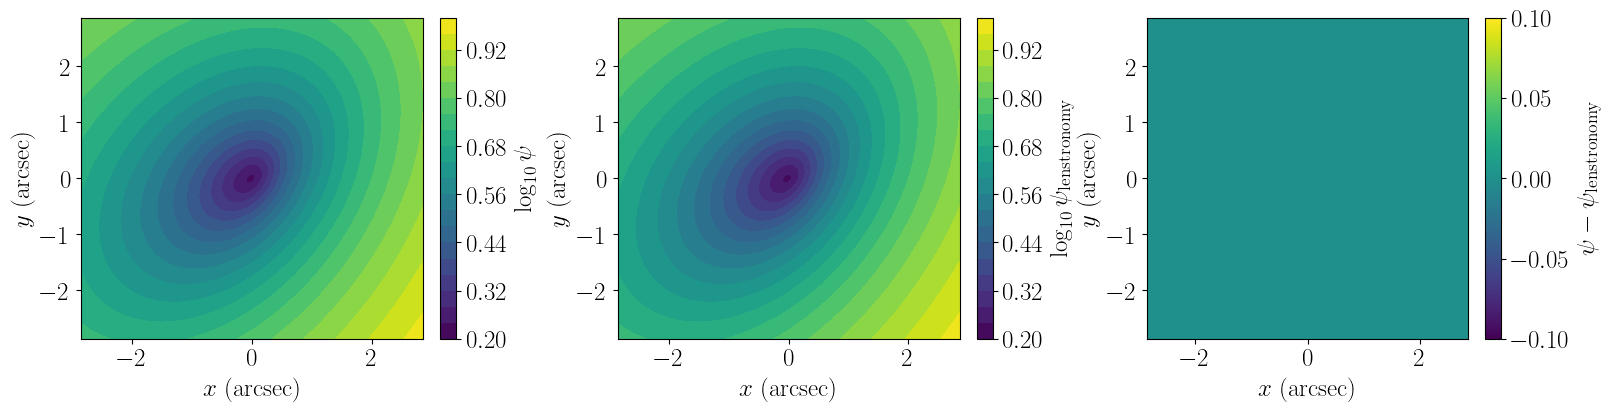

In [20]:
# plot the potential and compare with the direct implementation

fig, axes = plt.subplots(1, 3, figsize=(16, 4), layout="constrained")

contours = axes[0].contourf(X, Y, np.log10(potential), levels=20)
fig.colorbar(contours, ax=axes[0], label=r'$\log_{10}\psi$')

contours = axes[1].contourf(X, Y, np.log10(potential_lenstronomy), levels=20)
fig.colorbar(contours, ax=axes[1], label=r'$\log_{10}\psi_{\rm lenstronomy}$')

im = axes[2].imshow(potential - potential_lenstronomy, extent=(-2*theta_E, 2*theta_E, -2*theta_E, 2*theta_E))
fig.colorbar(im, ax=axes[2], label=r'$\psi - \psi_{\rm lenstronomy}$')

for ax in axes:
    ax.set_xlabel(r"$x$ (arcsec)")
    ax.set_ylabel(r"$y$ (arcsec)")

plt.show();

In [21]:
alpha_x_lenstronomy, alpha_y_lenstronomy = lens_model.alpha(X, Y, kwargs=kwargs_lens)
alpha_x, alpha_y = displacement(X, Y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)

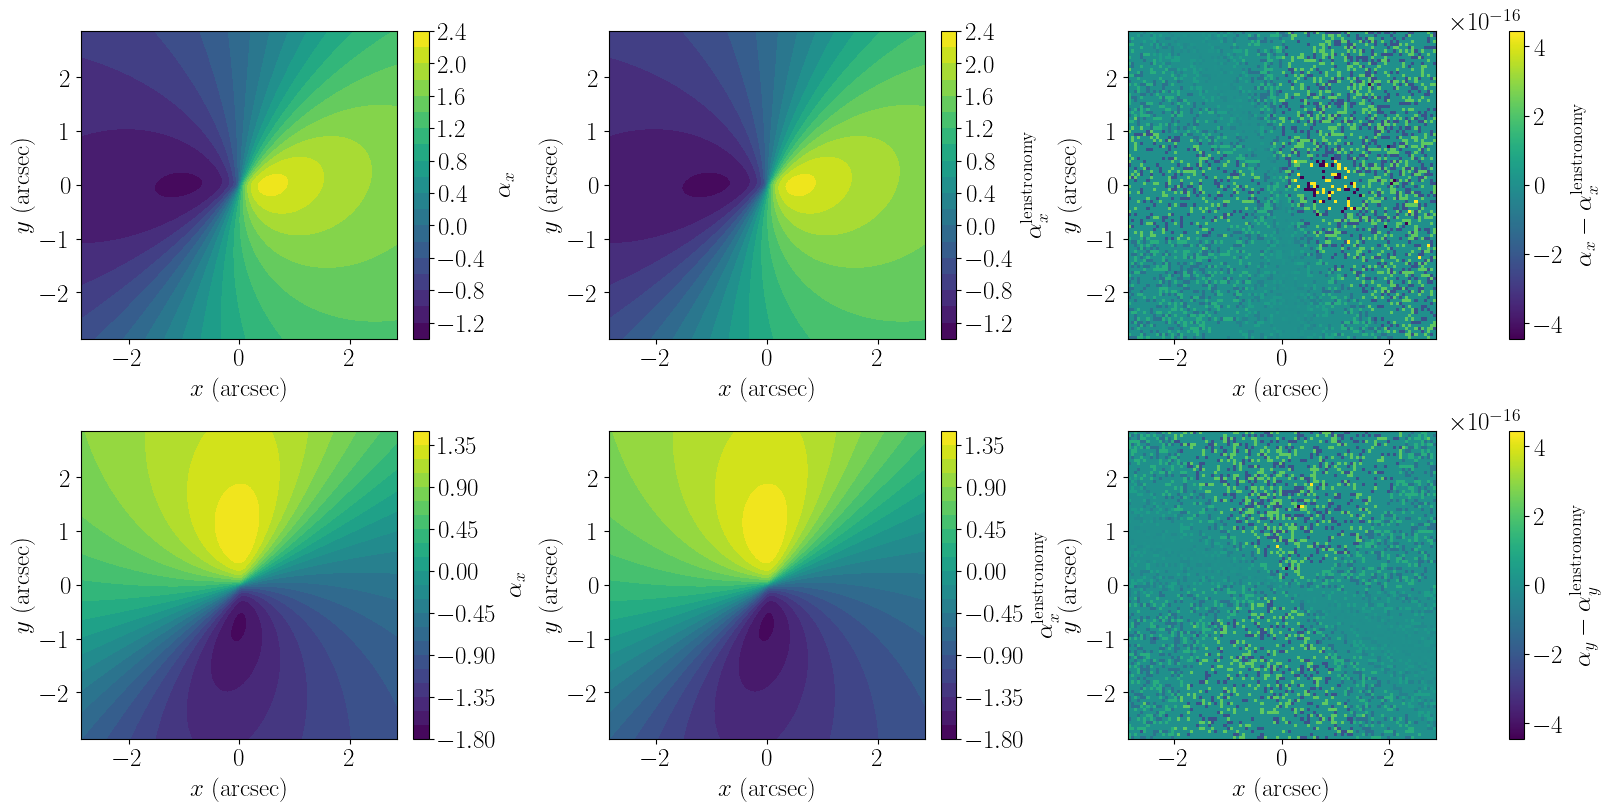

In [22]:
# plot the displacement and compare with the direct implementation

fig, axes = plt.subplots(2, 3, figsize=(16, 8), layout="constrained")

contours = axes[0, 0].contourf(X, Y, alpha_x, levels=20)
fig.colorbar(contours, ax=axes[0, 0], label=r'$\alpha_x$')

contours = axes[0, 1].contourf(X, Y, alpha_x_lenstronomy, levels=20)
fig.colorbar(contours, ax=axes[0, 1], label=r'$\alpha_x^{\rm lenstronomy}$')

im = axes[0, 2].imshow(alpha_x - alpha_x_lenstronomy, extent=(-2*theta_E, 2*theta_E, -2*theta_E, 2*theta_E))
fig.colorbar(im, ax=axes[0, 2], label=r'$\alpha_x - \alpha_x^{\rm lenstronomy}$')

contours = axes[1, 0].contourf(X, Y, alpha_y, levels=20)
fig.colorbar(contours, ax=axes[1, 0], label=r'$\alpha_x$')

contours = axes[1, 1].contourf(X, Y, alpha_y_lenstronomy, levels=20)
fig.colorbar(contours, ax=axes[1, 1], label=r'$\alpha_x^{\rm lenstronomy}$')

im = axes[1, 2].imshow(alpha_y - alpha_y_lenstronomy, extent=(-2*theta_E, 2*theta_E, -2*theta_E, 2*theta_E))
fig.colorbar(im, ax=axes[1, 2], label=r'$\alpha_y - \alpha_y^{\rm lenstronomy}$')

for i in range(2):
    for j in range(3):
        ax = axes[i, j]
        ax.set_xlabel(r"$x$ (arcsec)")
        ax.set_ylabel(r"$y$ (arcsec)")

plt.show();

In [23]:
# same with the Hessian matrix

H_xx_lenstronomy, H_xy_lenstronomy, H_yx_lenstronomy, H_yy_lenstronomy = lens_model.hessian(X, Y, kwargs=kwargs_lens)
H_xx, H_xy, H_yx, H_yy = hessian(X, Y, theta_E, theta_core, sharpness, outer_slope, e1, e2, drift_x, drift_y)

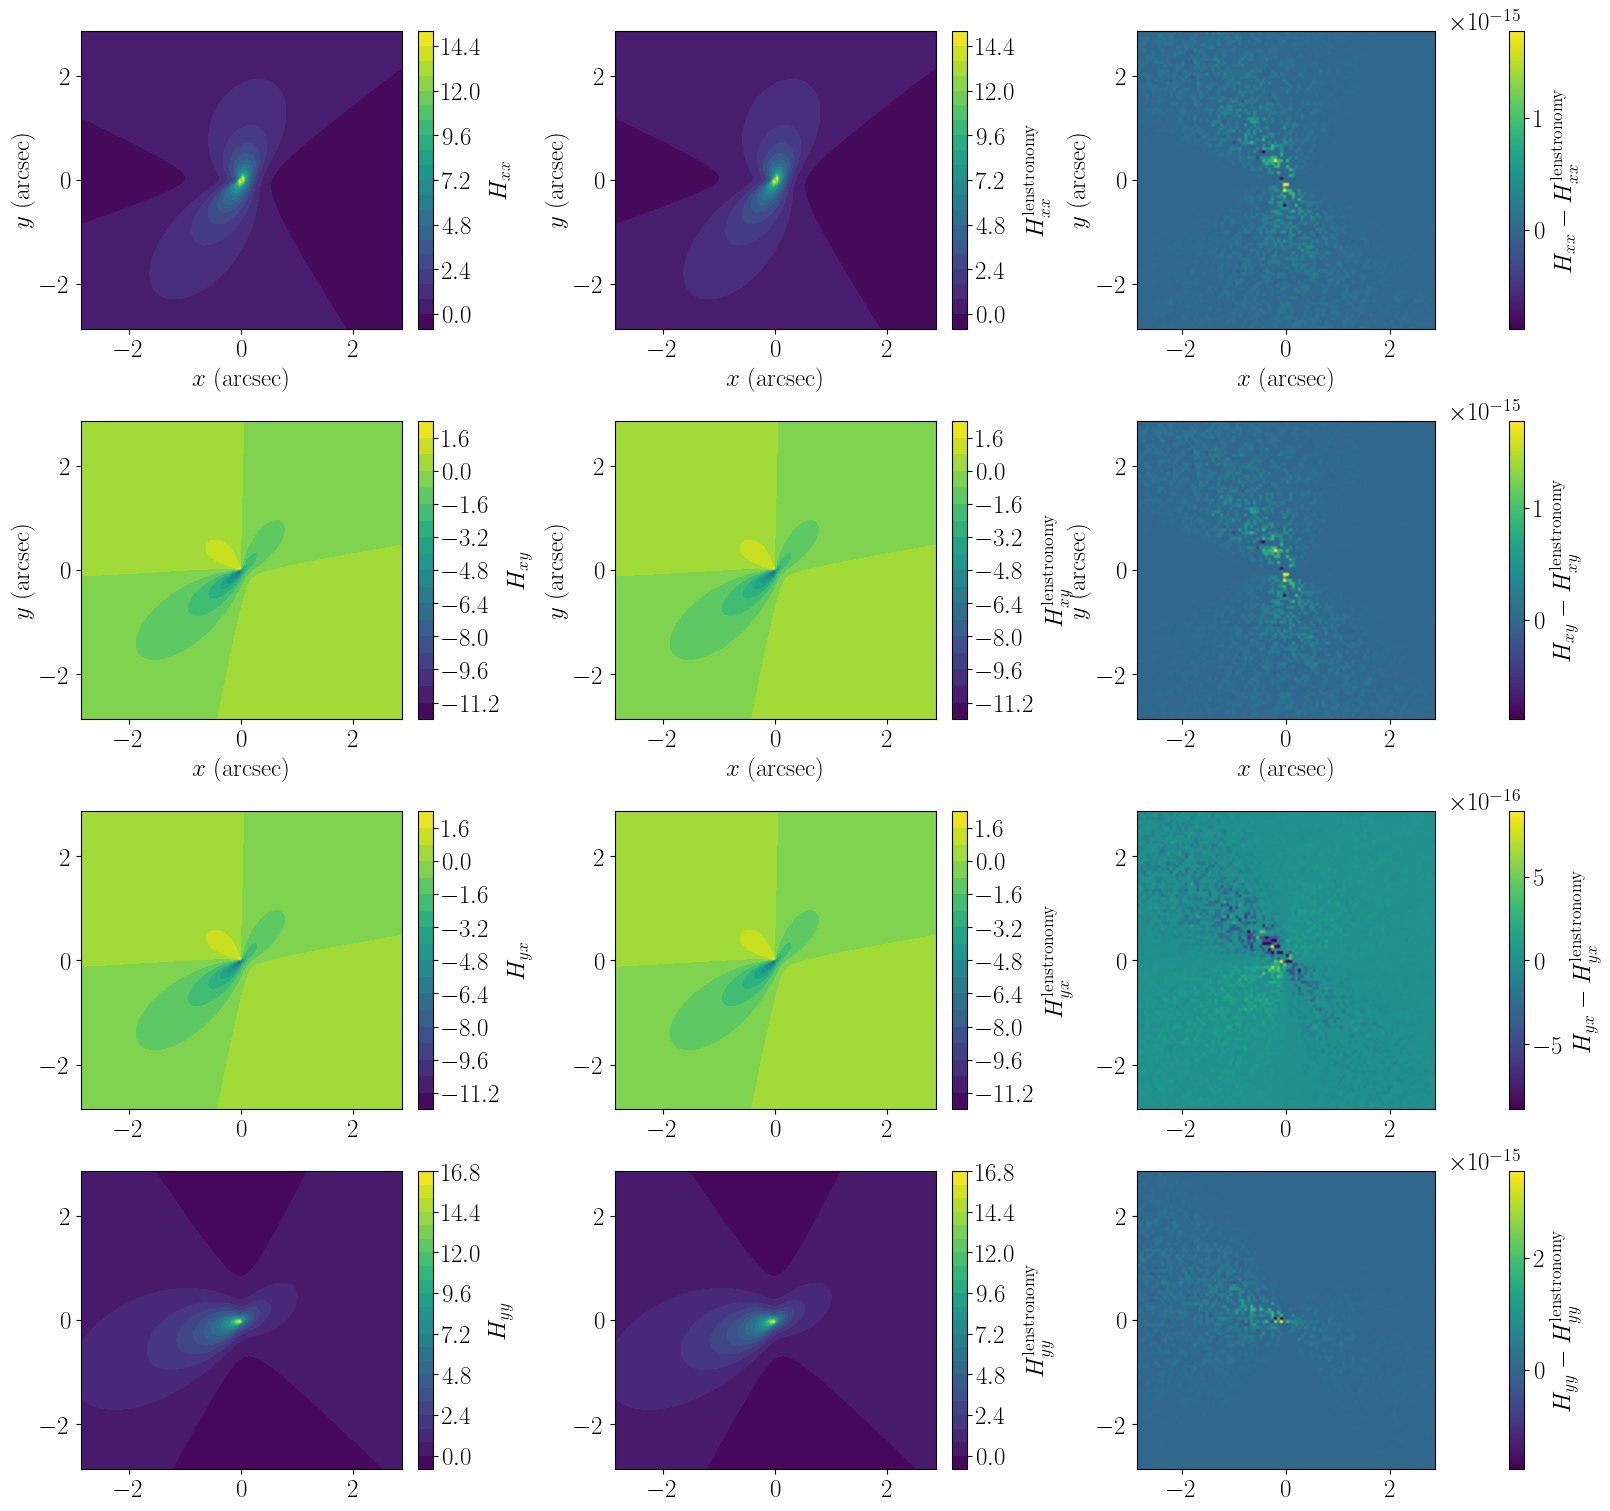

In [24]:
# plot the displacement and compare with the direct implementation

fig, axes = plt.subplots(4, 3, figsize=(16, 15), layout="constrained")

# H_xx

contours = axes[0, 0].contourf(X, Y, H_xx, levels=20)
fig.colorbar(contours, ax=axes[0, 0], label=r'$H_{xx}$')

contours = axes[0, 1].contourf(X, Y, H_xx_lenstronomy, levels=20)
fig.colorbar(contours, ax=axes[0, 1], label=r'$H_{xx}^{\rm lenstronomy}$')

im = axes[0, 2].imshow(H_xx - H_xx_lenstronomy, extent=(-2*theta_E, 2*theta_E, -2*theta_E, 2*theta_E))
fig.colorbar(im, ax=axes[0, 2], label=r'$H_{xx} - H_{xx}^{\rm lenstronomy}$')


# H_xy

contours = axes[1, 0].contourf(X, Y, H_xy, levels=20)
fig.colorbar(contours, ax=axes[1, 0], label=r'$H_{xy}$')

contours = axes[1, 1].contourf(X, Y, H_xy_lenstronomy, levels=20)
fig.colorbar(contours, ax=axes[1, 1], label=r'$H_{xy}^{\rm lenstronomy}$')

im = axes[1, 2].imshow(H_xx - H_xx_lenstronomy, extent=(-2*theta_E, 2*theta_E, -2*theta_E, 2*theta_E))
fig.colorbar(im, ax=axes[1, 2], label=r'$H_{xy} - H_{xy}^{\rm lenstronomy}$')


# H_yx

contours = axes[2, 0].contourf(X, Y, H_yx, levels=20)
fig.colorbar(contours, ax=axes[2, 0], label=r'$H_{yx}$')

contours = axes[2, 1].contourf(X, Y, H_yx_lenstronomy, levels=20)
fig.colorbar(contours, ax=axes[2, 1], label=r'$H_{yx}^{\rm lenstronomy}$')

im = axes[2, 2].imshow(H_yx - H_yx_lenstronomy, extent=(-2*theta_E, 2*theta_E, -2*theta_E, 2*theta_E))
fig.colorbar(im, ax=axes[2, 2], label=r'$H_{yx} - H_{yx}^{\rm lenstronomy}$')


# H_yy

contours = axes[3, 0].contourf(X, Y, H_yy, levels=20)
fig.colorbar(contours, ax=axes[3, 0], label=r'$H_{yy}$')

contours = axes[3, 1].contourf(X, Y, H_yy_lenstronomy, levels=20)
fig.colorbar(contours, ax=axes[3, 1], label=r'$H_{yy}^{\rm lenstronomy}$')

im = axes[3, 2].imshow(H_yy - H_yy_lenstronomy, extent=(-2*theta_E, 2*theta_E, -2*theta_E, 2*theta_E))
fig.colorbar(im, ax=axes[3, 2], label=r'$H_{yy} - H_{yy}^{\rm lenstronomy}$')


for i in range(2):
    for j in range(3):
        ax = axes[i, j]
        ax.set_xlabel(r"$x$ (arcsec)")
        ax.set_ylabel(r"$y$ (arcsec)")

plt.show();

# 3. Parametrising the drift rate

So far we have defined the drift rate as $\boldsymbol{D}=(D_x, D_y)$, which must satisfy the constraint $\boldsymbol{D}^T \boldsymbol{E} \boldsymbol{D} < 1$. This condition will be annoying to impose when we sample the parameters all at once. A solution is to choose a parameterisation of the drift such that the condition is always enforced. In addition, we wish the parameterisation to lead to a mostly uninformative prior if the parameters are uniformly sampled.

I propose the following:
$$
\boldsymbol{D}(N_D^2, \phi_D) =
\sqrt{N_D^2} \,\boldsymbol{E}^{-1/2}
\begin{pmatrix}
\cos\phi_D \\
\sin\phi_D
\end{pmatrix}
$$
with $N_D\in [0, 1]$, and $\phi_D\in [0, 2\pi]$ (elliptical angle). The matrix $\boldsymbol{E}^{-1/2}$ reads, explicitly
$$
\boldsymbol{E}^{-1/2}
=
\begin{bmatrix}
\cos\phi & -\sin\phi \\
\sin\phi & \cos\phi
\end{bmatrix}
\begin{bmatrix}
q^{-1/2} & 0 \\
0 & q^{1/2}
\end{bmatrix}
\begin{bmatrix}
\cos\phi & \sin\phi \\
-\sin\phi & \cos\phi
\end{bmatrix}
$$
where $q$ and $\phi$ are the axis ratio and the pointing angle of the elliptical model. It can be seen as the ellipse matrix with ellipticity components
$
\tilde{e}_i = \frac{\sqrt{q}}{1+q} \, e_i .
$

In [25]:
def ellipse_matrix(e1, e2):
    """
    Returns the matrix involved in the equation of an ellipse
    in rectangular coordinates.
    """

    E_xx = (1 + e1**2 + e2**2)**0.5 - e1
    E_xy = - e2
    E_yx = - e2
    E_yy = (1 + e1**2 + e2**2)**0.5 + e1

    return E_xx, E_xy, E_yx, E_yy


def EV(e1, e2, v_x, v_y):
    """
    Returns the vector E*V.
    """

    E_xx, E_xy, E_yx, E_yy = ellipse_matrix(e1, e2)

    EV_x = E_xx * v_x + E_xy * v_y
    EV_y = E_yx * v_x + E_yy * v_y
                    
    return EV_x, EV_y


def generate_drift(N2_D, phi_D, e1, e2):

    e = (e1**2 + e2**2)**0.5
    q = (1 + e**2)**0.5 - e
    etilde1 = - q**0.5 / (1 + q) * e1
    etilde2 = - q**0.5 / (1 + q) * e2
    N_D = N2_D**0.5

    drift_x, drift_y = EV(etilde1, etilde2, np.cos(2*phi_D), np.sin(2*phi_D))
    drift_x *= N_D
    drift_y *= N_D

    return drift_x, drift_y

Check that it fills the ellipse homogeneously

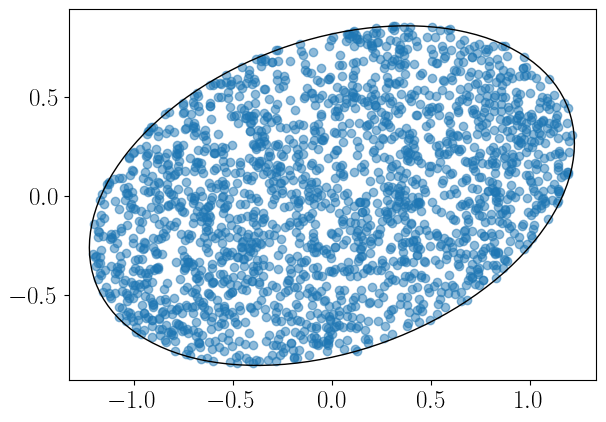

In [26]:
e       = 0.5
phi     = 0.35
e1      = e * np.cos(2*phi)
e2      = e * np.sin(2*phi)
e = (e1**2 + e2**2)**0.5
q = (1 + e**2)**0.5 - e
a = 1 / q**0.5
b = 1 * q**0.5

N = 2000
N2_D = np.random.rand(N)
phi_D = 2 * np.pi * np.random.rand(N)

drift_x, drift_y = generate_drift(N2_D, phi_D, e1, e2)

fig, ax = plt.subplots()
ax.scatter(drift_x, drift_y, alpha=0.5)
ellipse = Ellipse(xy=(0,0), width=2*a, height=2*b, angle=phi * 180 / np.pi, facecolor="none", edgecolor='k')
ax.add_artist(ellipse)
ax.set_aspect('equal', 'box')
fig.tight_layout()
plt.show();